# Movie Dataset — Exploratory Data Analysis

### End-to-end EDA on a TMDB movie dataset: cleaning messy raw data, then exploring ratings, popularity, genres, languages, and release trends.

# 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# 2. Load the data

In [2]:
df = pd.read_csv('mymoviedb.csv', sep=None, engine='python', on_bad_lines='skip')
print(df.shape)
df.head()

(9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


# 3. First look

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [4]:
df.isna().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [5]:
df.duplicated(subset='Title').sum()

np.int64(322)

# 4. Clean the data

In [6]:
df = df.dropna(subset=['Title', 'Genre']).copy()

df = df.drop_duplicates(subset='Title', keep='first')
for col in ['Popularity', 'Vote_Count', 'Vote_Average']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Popularity', 'Vote_Count', 'Vote_Average'])
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df = df.dropna(subset=['Release_Date'])
df['Year'] = df['Release_Date'].dt.year
df['Month'] = df['Release_Date'].dt.month_name()
df['Genre_List'] = df['Genre'].str.split(', ')

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (9512, 12)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year,Month,Genre_List
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,December,"[Action, Adventure, Science Fiction]"
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022,March,"[Crime, Mystery, Thriller]"
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022,February,[Thriller]
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021,November,"[Animation, Comedy, Family, Fantasy]"
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021,December,"[Action, Adventure, Thriller, War]"


# 5. Univariate distributions

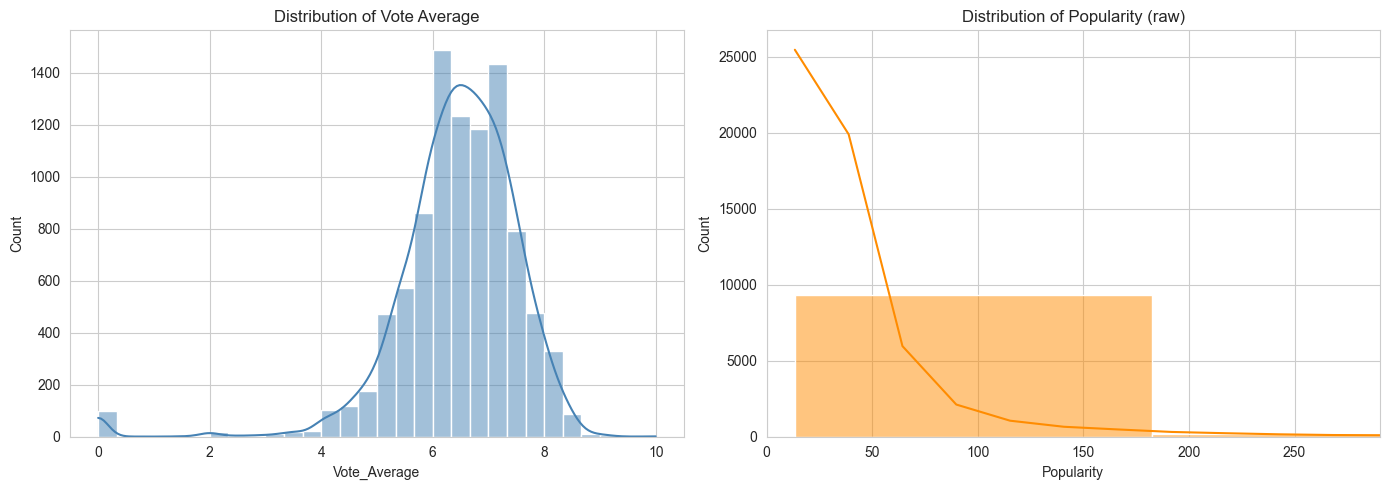

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Vote_Average'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Vote Average')

sns.histplot(df['Popularity'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Popularity (raw)')
axes[1].set_xlim(0, df['Popularity'].quantile(0.99))  
plt.tight_layout()
plt.savefig('distributions_1.png', dpi=150)
plt.show()

# 6. Language breakdown

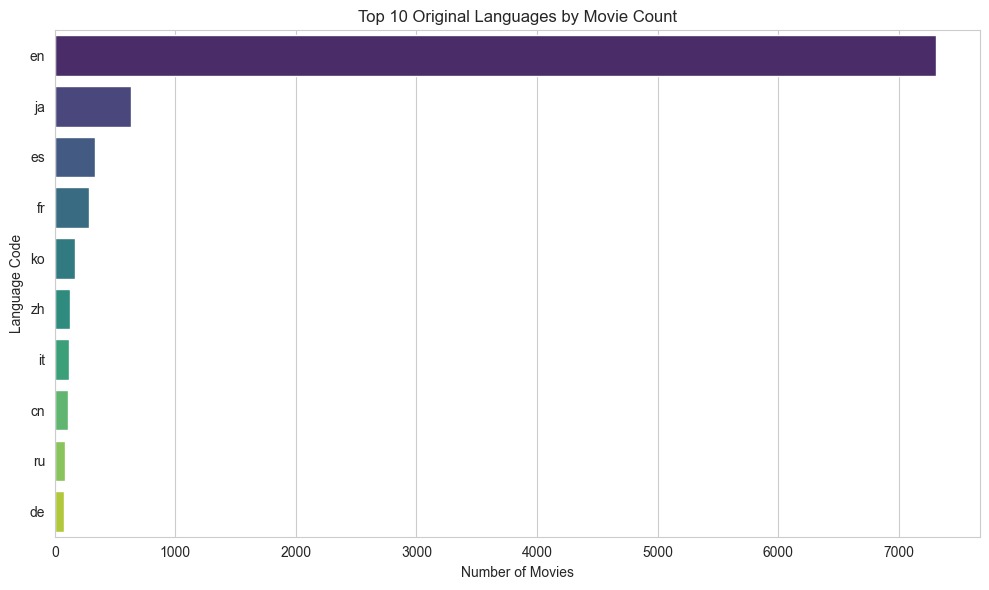

In [8]:
top_langs = df['Original_Language'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_langs.values, y=top_langs.index, hue=top_langs.index, palette='viridis', legend=False)
plt.title('Top 10 Original Languages by Movie Count')
plt.xlabel('Number of Movies')
plt.ylabel('Language Code')
plt.tight_layout()
plt.savefig('top_languages_2.png', dpi=150)
plt.show()

# 7. Genre analysis

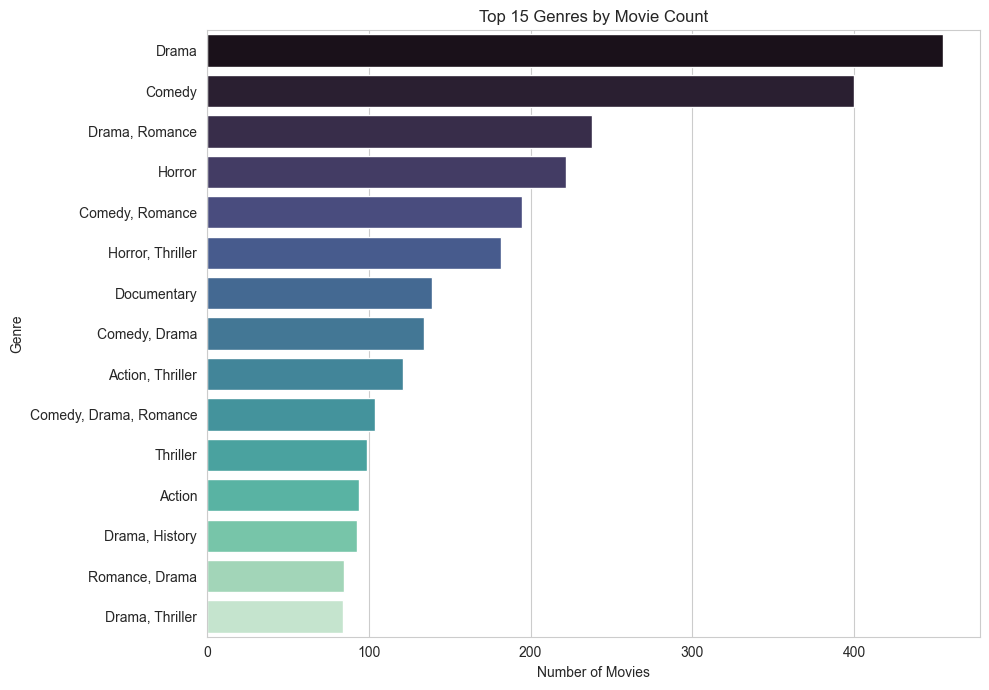

In [9]:
top_genres = df['Genre'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='mako', legend=False)
plt.title('Top 15 Genres by Movie Count')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('top_genres_3.png', dpi=150)
plt.show()

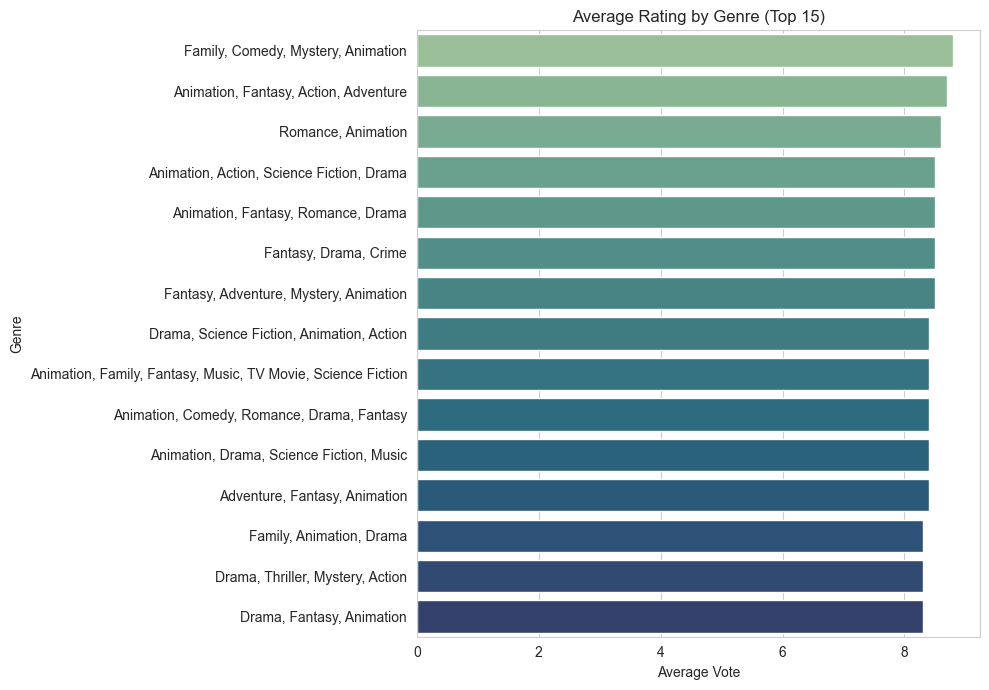

In [10]:
avg_rating_by_genre = (
    df.groupby('Genre')['Vote_Average']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10, 7))
sns.barplot(x=avg_rating_by_genre.values, y=avg_rating_by_genre.index, hue=avg_rating_by_genre.index, palette='crest', legend=False)
plt.title('Average Rating by Genre (Top 15)')
plt.xlabel('Average Vote')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('avg_rating_by_genre_4.png', dpi=150)
plt.show()

# 8. Release trends over time

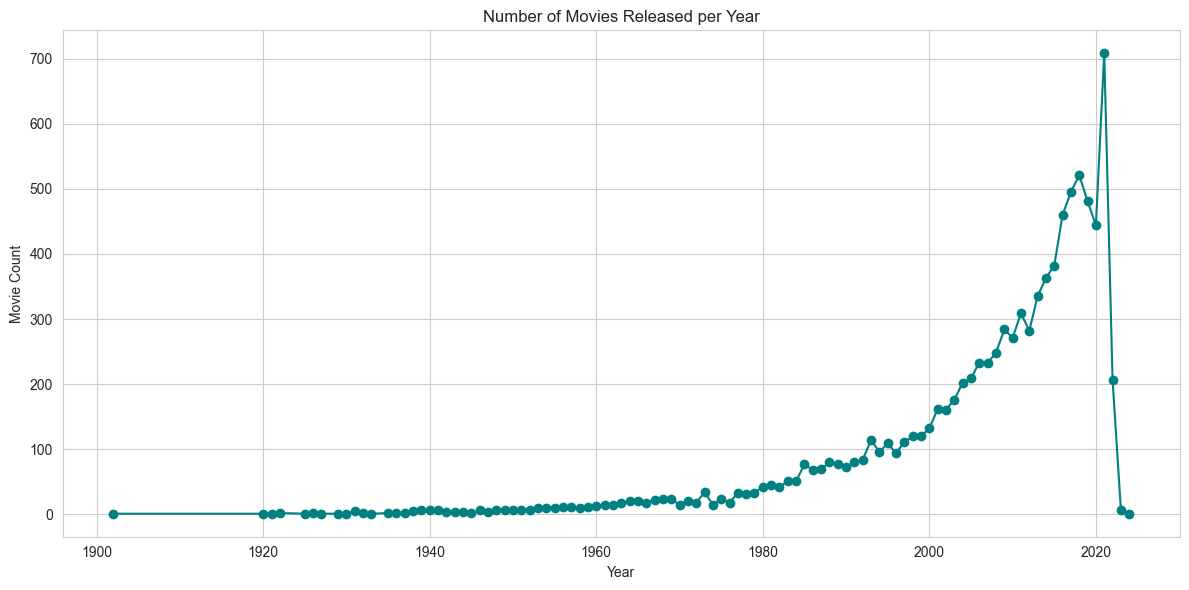

In [11]:
movies_per_year = df['Year'].value_counts().sort_index()
movies_per_year = movies_per_year[movies_per_year.index <= 2024] 

plt.figure(figsize=(12, 6))
movies_per_year.plot(kind='line', marker='o', color='teal')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Movie Count')
plt.tight_layout()
plt.savefig('movies_per_year_5.png', dpi=150)
plt.show()

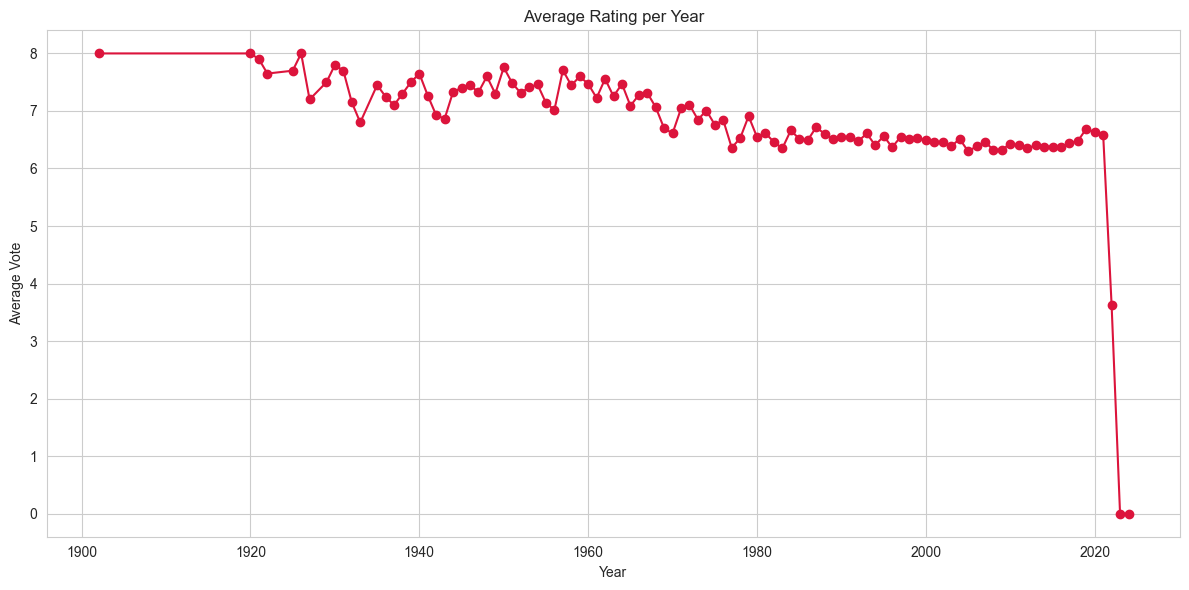

In [12]:
avg_rating_per_year = df.groupby('Year')['Vote_Average'].mean()
avg_rating_per_year = avg_rating_per_year[avg_rating_per_year.index <= 2024]

plt.figure(figsize=(12, 6))
avg_rating_per_year.plot(kind='line', marker='o', color='crimson')
plt.title('Average Rating per Year')
plt.xlabel('Year')
plt.ylabel('Average Vote')
plt.tight_layout()
plt.savefig('avg_rating_per_year_6.png', dpi=150)
plt.show()

# 9. Relationships between numeric variables

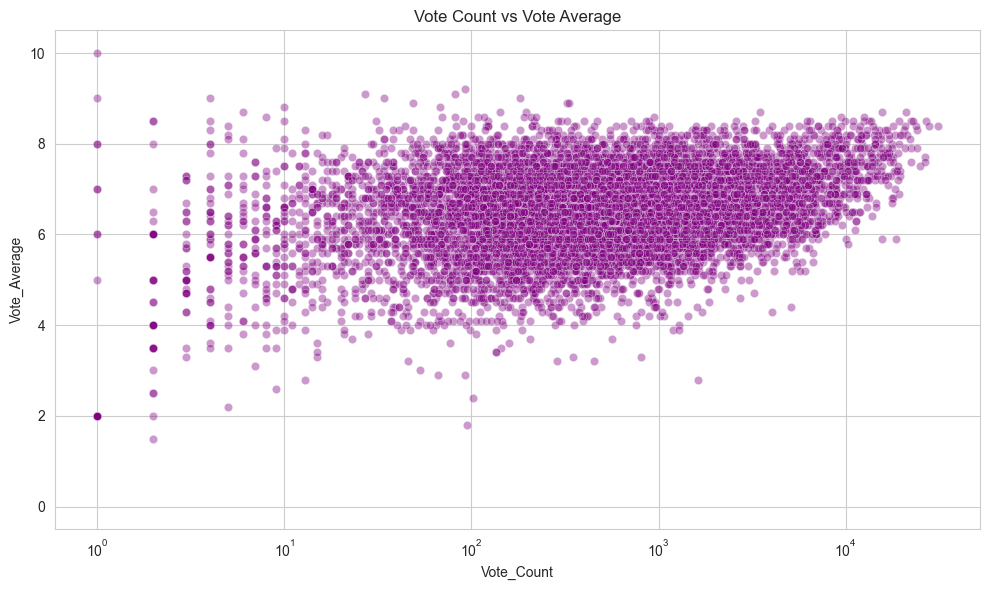

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Vote_Count', y='Vote_Average', alpha=0.4, color='purple')
plt.title('Vote Count vs Vote Average')
plt.xscale('log') 
plt.tight_layout()
plt.savefig('votecount_vs_rating_7.png', dpi=150)
plt.show()

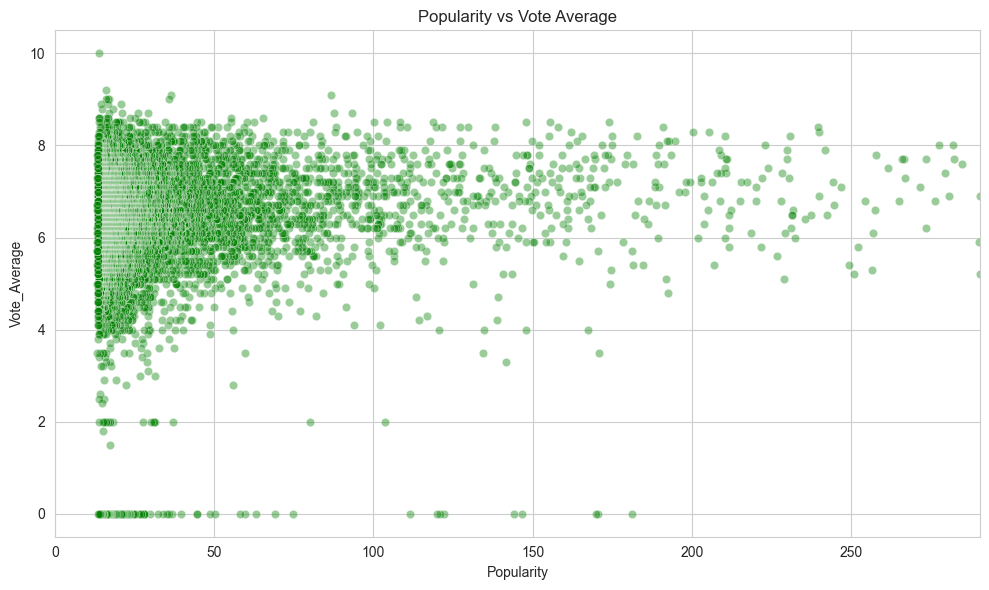

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Popularity', y='Vote_Average', alpha=0.4, color='green')
plt.title('Popularity vs Vote Average')
plt.xlim(0, df['Popularity'].quantile(0.99))
plt.tight_layout()
plt.savefig('popularity_vs_rating_8.png', dpi=150)
plt.show()

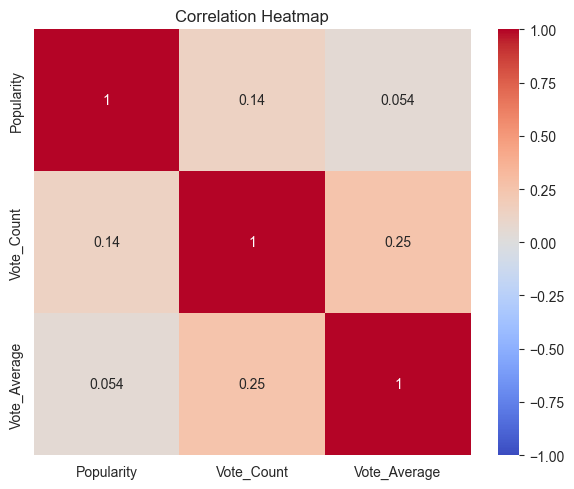

In [15]:
plt.figure(figsize=(6, 5))
corr = df[['Popularity', 'Vote_Count', 'Vote_Average']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap_9.png', dpi=150)
plt.show()

# 10. Top 10 lists

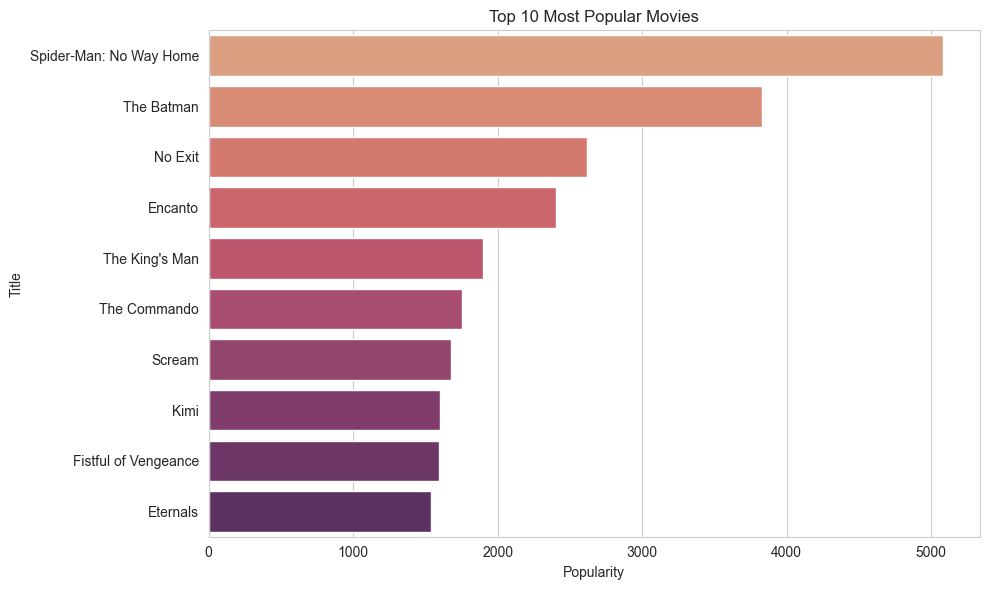

,Title,Popularity,Vote_Average,Genre
0,Spider-Man: No Way Home,5083.954,8.3,"Action, Adventure, Science Fiction"
1,The Batman,3827.658,8.1,"Crime, Mystery, Thriller"
2,No Exit,2618.087,6.3,Thriller
3,Encanto,2402.201,7.7,"Animation, Comedy, Family, Fantasy"
4,The King's Man,1895.511,7.0,"Action, Adventure, Thriller, War"
5,The Commando,1750.484,6.6,"Action, Crime, Thriller"
6,Scream,1675.161,6.8,"Horror, Mystery, Thriller"
7,Kimi,1601.782,6.3,Thriller
8,Fistful of Vengeance,1594.013,5.3,"Action, Crime, Fantasy"
9,Eternals,1537.406,7.2,Science Fiction


In [16]:
top_popular = df.nlargest(10, 'Popularity')[['Title', 'Popularity', 'Vote_Average', 'Genre']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Popularity', y='Title', data=top_popular, hue='Title', palette='flare', legend=False)
plt.title('Top 10 Most Popular Movies')
plt.tight_layout()
plt.savefig('top10_popular_10.png', dpi=150)
plt.show()

top_popular

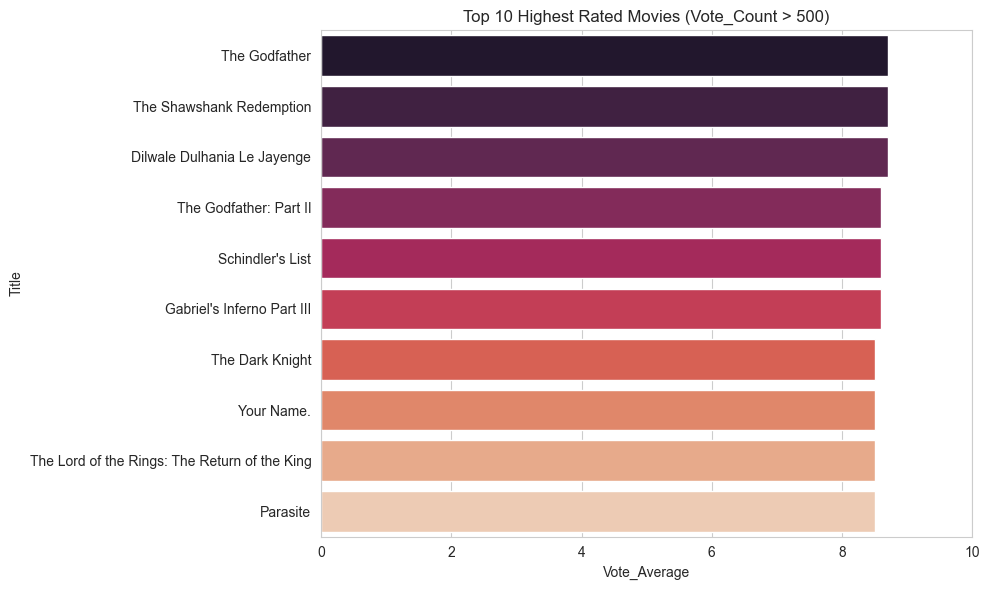

,Title,Vote_Average,Vote_Count,Genre
609,The Godfather,8.7,15614,"Drama, Crime"
657,The Shawshank Redemption,8.7,20911,"Drama, Crime"
3156,Dilwale Dulhania Le Jayenge,8.7,3474,"Comedy, Drama, Romance"
1007,The Godfather: Part II,8.6,9393,"Drama, Crime"
1327,Schindler's List,8.6,12474,"Drama, History, War"
4196,Gabriel's Inferno Part III,8.6,946,"Romance, Comedy"
221,The Dark Knight,8.5,26994,"Drama, Action, Crime, Thriller"
278,Your Name.,8.5,8426,"Romance, Animation, Drama"
419,The Lord of the Rings: The Return of the King,8.5,19183,"Adventure, Fantasy, Action"
480,Parasite,8.5,13240,"Comedy, Thriller, Drama"


In [17]:
reliable = df[df['Vote_Count'] > 500]
top_rated = reliable.nlargest(10, 'Vote_Average')[['Title', 'Vote_Average', 'Vote_Count', 'Genre']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Vote_Average', y='Title', data=top_rated, hue='Title', palette='rocket', legend=False)
plt.title('Top 10 Highest Rated Movies (Vote_Count > 500)')
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig('top10_rated_11.png', dpi=150)
plt.show()

top_rated

# 11. Key Takeaways

#### - Ratings mostly fall between 6-8.
#### - English movies dominate the dataset.
#### - Drama and Comedy are the most common genres.
#### - Animation genres tend to have the highest ratings.
#### - Movie releases increased steadily over the years.
#### - Popularity and rating are not strongly related — popular ≠ well-rated.
#### - Most popular movies and highest rated movies are usually different.